Fetching https://noaadata.apps.nsidc.org/NOAA/G02135/north/daily/data/N_seaice_extent_daily_v4.0.csv …
Loaded 1,227 daily records for years [2023, 2024, 2025, 2026]
  2023: 365 days
  2024: 366 days
  2025: 365 days
  2026: 131 days
Saved → arctic_sea_ice_comparison.png


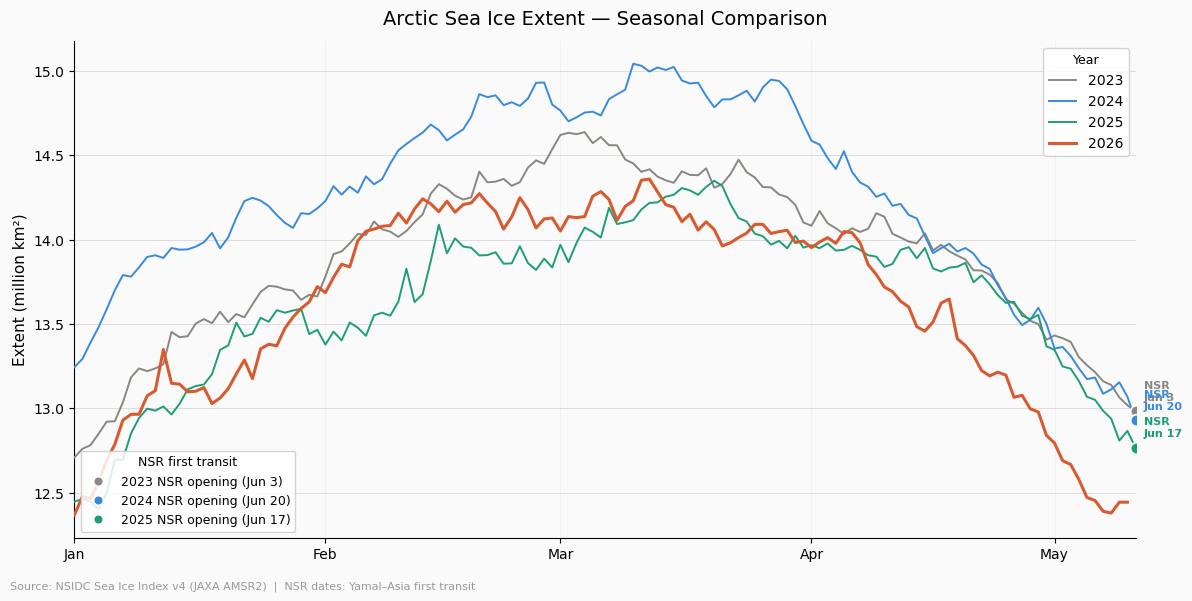

In [2]:
"""
Arctic Sea Ice Extent — Multi-year comparison with NSR opening dates
Data: NSIDC Sea Ice Index v4 (JAXA AMSR2)
https://noaadata.apps.nsidc.org/NOAA/G02135/north/daily/data/N_seaice_extent_daily_v4.0.csv
"""

import datetime
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

# ── Config ────────────────────────────────────────────────────────────────────

NSIDC_URL = (
    "https://noaadata.apps.nsidc.org/NOAA/G02135/north/daily/data/"
    "N_seaice_extent_daily_v4.0.csv"
)

YEARS = [2023, 2024, 2025, 2026]

COLORS = {
    2023: "#888780",
    2024: "#378ADD",
    2025: "#1D9E75",
    2026: "#D85A30",
}

LINEWIDTHS = {2023: 1.4, 2024: 1.4, 2025: 1.4, 2026: 2.2}

# Northern Sea Route first-transit dates (Yamal to Asia)
NSR_DATES = {
    2023: datetime.date(2023, 6, 3),
    2024: datetime.date(2024, 6, 20),
    2025: datetime.date(2025, 6, 17),
}

# Restrict x-axis to Jan 1 – present (using a common year for alignment)
PLOT_END_DOY = datetime.date.today().timetuple().tm_yday


# ── Data fetch & parse ────────────────────────────────────────────────────────

def fetch_nsidc(url: str) -> pd.DataFrame:
    print(f"Fetching {url} …")
    r = requests.get(url, timeout=30)
    r.raise_for_status()

    from io import StringIO
    # Skip the two-line header (row 0 = column names, row 1 = units)
    df = pd.read_csv(
        StringIO(r.text),
        skiprows=2,
        header=None,
        names=["Year", "Month", "Day", "Extent", "Missing", "Source"],
        skipinitialspace=True,
    )
    df = df[["Year", "Month", "Day", "Extent"]].dropna()
    df = df[df["Extent"] > 0].copy()
    df["Year"] = df["Year"].astype(int)
    df["Month"] = df["Month"].astype(int)
    df["Day"] = df["Day"].astype(int)
    df["Extent"] = df["Extent"].astype(float)

    # Build a day-of-year column for alignment across years
    df["DOY"] = df.apply(
        lambda r: datetime.date(int(r.Year), int(r.Month), int(r.Day)).timetuple().tm_yday, axis=1
    )
    # Fake date anchored to 2000 for x-axis alignment
    df["PlotDate"] = df["DOY"].apply(
        lambda d: datetime.date(2000, 1, 1) + datetime.timedelta(days=int(d) - 1)
    )
    return df


# ── Plot ──────────────────────────────────────────────────────────────────────

def make_plot(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor("#fafafa")
    ax.set_facecolor("#fafafa")

    plot_start = datetime.date(2000, 1, 1)
    plot_end = datetime.date(2000, 1, 1) + datetime.timedelta(days=PLOT_END_DOY - 1)

    nsr_handles = []

    for yr in YEARS:
        subset = df[df["Year"] == yr].sort_values("DOY")
        if subset.empty:
            print(f"  No data for {yr}")
            continue

        # Clip to current DOY so future years don't show blank trailing line
        subset = subset[subset["DOY"] <= PLOT_END_DOY]

        ax.plot(
            subset["PlotDate"],
            subset["Extent"],
            color=COLORS[yr],
            linewidth=LINEWIDTHS[yr],
            label=str(yr),
            zorder=3,
        )

        # NSR opening date marker
        if yr in NSR_DATES:
            nsr = NSR_DATES[yr]
            nsr_doy = nsr.timetuple().tm_yday
            match = subset[subset["DOY"] == nsr_doy]
            if match.empty:
                # nearest day
                match = subset.iloc[(subset["DOY"] - nsr_doy).abs().argsort()[:1]]
            if not match.empty:
                x = match["PlotDate"].values[0]
                y = match["Extent"].values[0]
                ax.scatter(x, y, s=70, color=COLORS[yr], zorder=5,
                           edgecolors="white", linewidths=1.2)
                ax.annotate(
                    f"NSR\n{nsr.strftime('%b %-d')}",
                    xy=(x, y),
                    xytext=(6, 8),
                    textcoords="offset points",
                    fontsize=8,
                    color=COLORS[yr],
                    fontweight="bold",
                )
                nsr_handles.append(
                    Line2D([0], [0], marker="o", color="none",
                           markerfacecolor=COLORS[yr], markeredgecolor="white",
                           markeredgewidth=1.2, markersize=7,
                           label=f"{yr} NSR opening ({nsr.strftime('%b %-d')})")
                )

    # Axes formatting
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_xlim(plot_start, plot_end)
    ax.set_ylabel("Extent (million km²)", fontsize=11)
    ax.set_xlabel("")
    ax.set_title("Arctic Sea Ice Extent — Seasonal Comparison", fontsize=14, pad=12)
    ax.grid(axis="y", color="#dddddd", linewidth=0.7, zorder=0)
    ax.grid(axis="x", color="#eeeeee", linewidth=0.5, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)

    # Legend: year lines + NSR markers
    year_handles = [
        Line2D([0], [0], color=COLORS[yr], linewidth=LINEWIDTHS[yr], label=str(yr))
        for yr in YEARS if not df[df["Year"] == yr].empty
    ]
    legend1 = ax.legend(
        handles=year_handles, loc="upper right", fontsize=10,
        framealpha=0.85, title="Year", title_fontsize=9
    )
    ax.add_artist(legend1)
    if nsr_handles:
        ax.legend(
            handles=nsr_handles, loc="lower left", fontsize=9,
            framealpha=0.85, title="NSR first transit", title_fontsize=9
        )

    # Source note
    fig.text(
        0.01, 0.01,
        "Source: NSIDC Sea Ice Index v4 (JAXA AMSR2)  |  "
        "NSR dates: Yamal–Asia first transit",
        fontsize=8, color="#999999"
    )

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    out = "arctic_sea_ice_comparison.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved → {out}")
    plt.show()


# ── Main ──────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    df = fetch_nsidc(NSIDC_URL)
    df_filtered = df[df["Year"].isin(YEARS)]
    print(f"Loaded {len(df_filtered):,} daily records for years {YEARS}")
    for yr in YEARS:
        n = (df_filtered["Year"] == yr).sum()
        print(f"  {yr}: {n} days")
    make_plot(df_filtered)

Fetching https://noaadata.apps.nsidc.org/NOAA/G02135/north/daily/data/N_seaice_extent_daily_v4.0.csv …
Total Arctic: 1,227 daily records for [2023, 2024, 2025, 2026]
Fetching https://noaadata.apps.nsidc.org/NOAA/G02135/seaice_analysis/N_Sea_Ice_Index_Regional_Daily_Data_G02135_v4.0.xlsx …
  Sheets in workbook (first 10): ['Baffin-Area-km^2', 'Baffin-Extent-km^2', 'Barents-Area-km^2', 'Barents-Extent-km^2', 'Beaufort-Area-km^2', 'Beaufort-Extent-km^2', 'Bering-Area-km^2', 'Bering-Extent-km^2', 'CanadianArchipelago-Area-km^2', 'CanadianArchipelago-Extent-km^2']
NSR Corridor: 1,464 year-day records
  2023: 365 non-missing days
  2024: 366 non-missing days
  2025: 365 non-missing days
  2026: 131 non-missing days
Saved → arctic_sea_ice_nsr_corridor.png


/var/folders/bp/s09xxbsn5s9f7lpwh_5nyrsr0000gn/T/ipykernel_40612/2501983877.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 1])


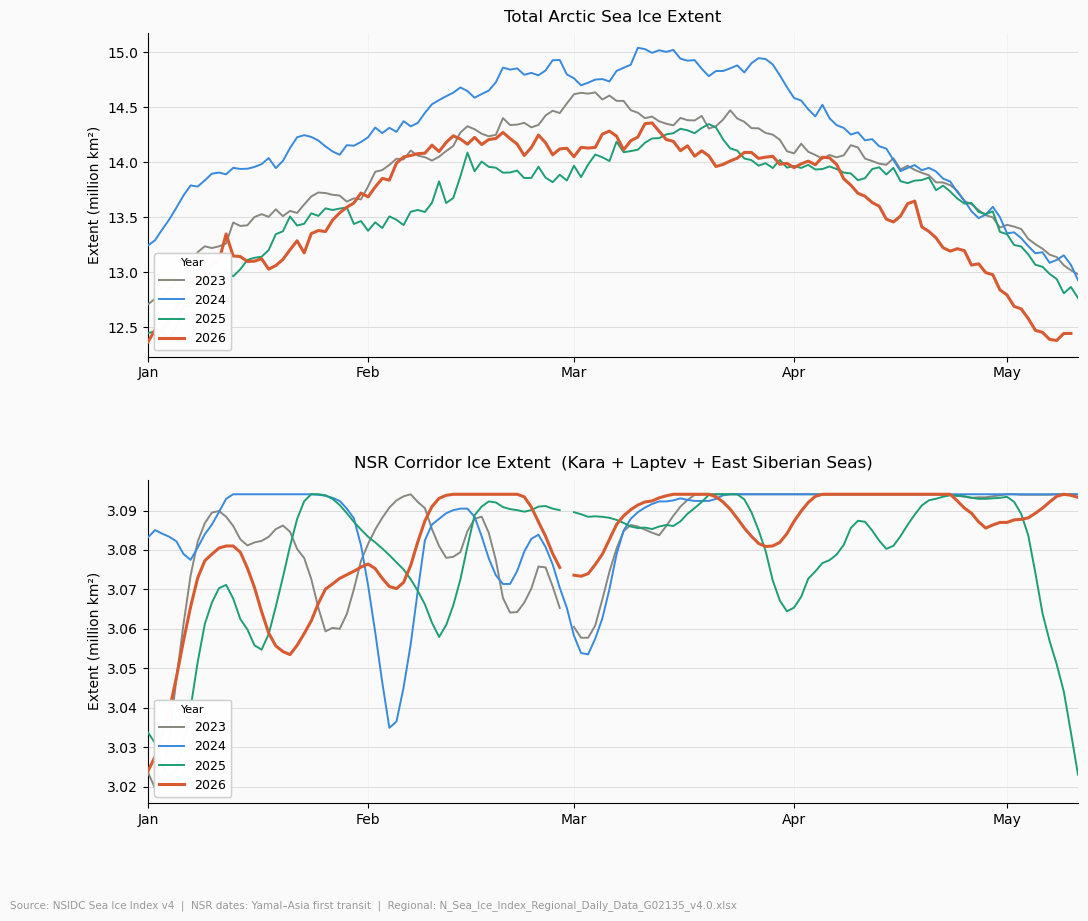

In [13]:
"""
Arctic Sea Ice Extent — Multi-year comparison with NSR opening dates
Data: NSIDC Sea Ice Index v4

Two panels:
  Top:    Total Arctic extent  (N_seaice_extent_daily_v4.0.csv)
  Bottom: NSR corridor extent  (Kara + Laptev + East Siberian seas)
          from N_Sea_Ice_Index_Regional_Daily_Data_G02135_v4.0.xlsx

The regional workbook has one sheet per region per variable.
Sheet naming pattern: "<Region>-Extent"  (e.g. "Kara Sea-Extent")
Layout: row 0 = header, col 0 = Year, cols 1–366 = DOY 1–366 (km²).
Values are in km²; we convert to million km² for plotting.
"""

import datetime
import io
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

# ── Config ────────────────────────────────────────────────────────────────────

NSIDC_TOTAL_URL = (
    "https://noaadata.apps.nsidc.org/NOAA/G02135/north/daily/data/"
    "N_seaice_extent_daily_v4.0.csv"
)

NSIDC_REGIONAL_URL = (
    "https://noaadata.apps.nsidc.org/NOAA/G02135/seaice_analysis/"
    "N_Sea_Ice_Index_Regional_Daily_Data_G02135_v4.0.xlsx"
)

YEARS = [2023, 2024, 2025, 2026]

COLORS = {
    2023: "#888780",
    2024: "#378ADD",
    2025: "#1D9E75",
    2026: "#D85A30",
}

LINEWIDTHS = {2023: 1.4, 2024: 1.4, 2025: 1.4, 2026: 2.2}

# NSR first-transit dates (Yamal to Asia)
NSR_DATES = {
    2023: datetime.date(2023, 6, 3),
    2024: datetime.date(2024, 6, 20),
    2025: datetime.date(2025, 6, 17),
}

# NSR corridor: the three seas the route traverses west→east
# Keys must match the sheet name prefix before "-Extent-km^2"
NSR_REGIONS = ["Kara", "Laptev", "East-Siberian"]

# Sheet name pattern in the regional workbook
def extent_sheet(region: str) -> str:
    return f"{region}-Extent-km^2"

PLOT_END_DOY = datetime.date.today().timetuple().tm_yday


# ── Fetch helpers ─────────────────────────────────────────────────────────────

def fetch_bytes(url: str) -> bytes:
    print(f"Fetching {url} …")
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return r.content


# ── Total Arctic extent (CSV) ─────────────────────────────────────────────────

def parse_total_csv(raw: bytes) -> pd.DataFrame:
    df = pd.read_csv(
        io.StringIO(raw.decode()),
        skiprows=2,
        header=None,
        names=["Year", "Month", "Day", "Extent", "Missing", "Source"],
        skipinitialspace=True,
    )
    df = df[["Year", "Month", "Day", "Extent"]].dropna()
    df = df[df["Extent"] > 0].copy()
    df["Year"]   = df["Year"].astype(int)
    df["Month"]  = df["Month"].astype(int)
    df["Day"]    = df["Day"].astype(int)
    df["Extent"] = df["Extent"].astype(float)
    df["DOY"] = df.apply(
        lambda r: datetime.date(int(r.Year), int(r.Month), int(r.Day)).timetuple().tm_yday,
        axis=1,
    )
    df["PlotDate"] = df["DOY"].apply(
        lambda d: datetime.date(2000, 1, 1) + datetime.timedelta(days=int(d) - 1)
    )
    return df[df["Year"].isin(YEARS)]


# ── Regional extent (Excel) ───────────────────────────────────────────────────

def parse_regional_xlsx(raw: bytes, regions: list[str]) -> pd.DataFrame:
    """
    Read the NSIDC regional daily Excel workbook and return a tidy DataFrame:
        Year | DOY | <region1> | <region2> | ... | NSR_Corridor | PlotDate

    Actual sheet layout (confirmed from file inspection):
        Row 0:  'month', 'day', 1978.0, 1979.0, ... 2026.0  (years as float cols)
        Rows 1–366: month label, day-of-month, extent in km² per year column
    Rows = DOY (sequential 1–366), columns = years.
    """
    xf = pd.ExcelFile(io.BytesIO(raw))
    available_sheets = xf.sheet_names
    print(f"  Sheets in workbook (first 10): {available_sheets[:10]}")

    region_dfs = {}
    for region in regions:
        sheet = extent_sheet(region)
        if sheet not in available_sheets:
            match = next(
                (s for s in available_sheets if s.lower() == sheet.lower()), None
            )
            if match is None:
                print(f"  WARNING: sheet '{sheet}' not found — skipping {region}")
                continue
            sheet = match

        raw_df = xf.parse(sheet, header=None)

        # Row 0 is the header; data rows 1–366 are DOY 1–366
        header = raw_df.iloc[0]
        data   = raw_df.iloc[1:].reset_index(drop=True)
        data["DOY"] = data.index + 1  # 1-based

        # Find year columns: header cells that parse to an int in 1978–2030
        year_col_map = {}  # year (int) -> column position in raw_df
        for col_idx, val in enumerate(header):
            try:
                yr = int(float(val))
                if 1978 <= yr <= 2030 and yr in YEARS:
                    year_col_map[yr] = col_idx
            except (ValueError, TypeError):
                pass

        if not year_col_map:
            print(f"  WARNING: no matching years found in '{sheet}' — skipping")
            continue

        # Build long-form rows
        rows = []
        for yr, col_idx in year_col_map.items():
            vals = pd.to_numeric(data.iloc[:, col_idx], errors="coerce")
            vals[vals <= 0] = np.nan
            rows.append(pd.DataFrame({
                "Year": yr,
                "DOY":  data["DOY"].values,
                region: (vals / 1e6).values,   # km² → million km²
            }))

        melted = pd.concat(rows, ignore_index=True)
        melted["DOY"] = melted["DOY"].astype(int)
        region_dfs[region] = melted.set_index(["Year", "DOY"])

    if not region_dfs:
        raise RuntimeError(
            "No regional sheets could be parsed. "
            f"Available sheets: {available_sheets}"
        )

    # Join all regions on (Year, DOY)
    combined = pd.concat(region_dfs.values(), axis=1).reset_index()
    combined["NSR_Corridor"] = combined[list(region_dfs.keys())].sum(
        axis=1, min_count=1
    )
    combined["PlotDate"] = combined["DOY"].apply(
        lambda d: datetime.date(2000, 1, 1) + datetime.timedelta(days=int(d) - 1)
    )
    return combined


# ── Plot helpers ──────────────────────────────────────────────────────────────

def add_nsr_markers(ax, df_year: pd.DataFrame, yr: int, y_col: str):
    """Add dot + annotation for the NSR first-transit date on an axes."""
    if yr not in NSR_DATES:
        return
    nsr     = NSR_DATES[yr]
    nsr_doy = nsr.timetuple().tm_yday
    row = df_year.iloc[(df_year["DOY"] - nsr_doy).abs().argsort()[:1]]
    if row.empty or pd.isna(row[y_col].values[0]):
        return
    x = row["PlotDate"].values[0]
    y = row[y_col].values[0]
    ax.scatter(x, y, s=70, color=COLORS[yr], zorder=5,
               edgecolors="white", linewidths=1.2)
    ax.annotate(
        f"NSR\n{nsr.strftime('%b %-d')}",
        xy=(x, y), xytext=(6, 8), textcoords="offset points",
        fontsize=8, color=COLORS[yr], fontweight="bold",
    )


def style_ax(ax, title: str, ylabel: str):
    plot_start = datetime.date(2000, 1, 1)
    plot_end   = datetime.date(2000, 1, 1) + datetime.timedelta(days=PLOT_END_DOY - 1)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_xlim(plot_start, plot_end)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=12, pad=8)
    ax.grid(axis="y", color="#dddddd", linewidth=0.7, zorder=0)
    ax.grid(axis="x", color="#eeeeee", linewidth=0.5, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)


# ── Main plot ─────────────────────────────────────────────────────────────────

def make_plot(df_total: pd.DataFrame, df_regional: pd.DataFrame):
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(12, 10), sharex=False,
        gridspec_kw={"hspace": 0.38},
    )
    fig.patch.set_facecolor("#fafafa")
    for ax in (ax_top, ax_bot):
        ax.set_facecolor("#fafafa")

    nsr_handles = []

    # ── Top: total Arctic ─────────────────────────────────────────────────────
    for yr in YEARS:
        sub = df_total[df_total["Year"] == yr].sort_values("DOY")
        sub = sub[sub["DOY"] <= PLOT_END_DOY]
        if sub.empty:
            continue
        ax_top.plot(sub["PlotDate"], sub["Extent"],
                    color=COLORS[yr], linewidth=LINEWIDTHS[yr], zorder=3)
        #add_nsr_markers(ax_top, sub, yr, "Extent")

    style_ax(ax_top, "Total Arctic Sea Ice Extent", "Extent (million km²)")

    # ── Bottom: NSR corridor ──────────────────────────────────────────────────
    for yr in YEARS:
        sub = df_regional[df_regional["Year"] == yr].sort_values("DOY")
        sub = sub[sub["DOY"] <= PLOT_END_DOY]
        if sub.empty or sub["NSR_Corridor"].isna().all():
            print(f"  No NSR corridor data for {yr}")
            continue
        ax_bot.plot(sub["PlotDate"], sub["NSR_Corridor"],
                    color=COLORS[yr], linewidth=LINEWIDTHS[yr], zorder=3)
        #add_nsr_markers(ax_bot, sub, yr, "NSR_Corridor")

        if yr in NSR_DATES:
            nsr = NSR_DATES[yr]
            nsr_handles.append(
                Line2D(
                    [0], [0], marker="o", color="none",
                    markerfacecolor=COLORS[yr], markeredgecolor="white",
                    markeredgewidth=1.2, markersize=7,
                    label=f"{yr} NSR opening ({nsr.strftime('%b %-d')})",
                )
            )

    style_ax(
        ax_bot,
        "NSR Corridor Ice Extent  (Kara + Laptev + East Siberian Seas)",
        "Extent (million km²)",
    )

    # ── Legends ───────────────────────────────────────────────────────────────
    year_handles = [
        Line2D([0], [0], color=COLORS[yr], linewidth=LINEWIDTHS[yr], label=str(yr))
        for yr in YEARS
    ]
    for ax in (ax_top, ax_bot):
        leg = ax.legend(handles=year_handles, loc="lower left", fontsize=9,
                        framealpha=0.85, title="Year", title_fontsize=8)
        ax.add_artist(leg)

    # if nsr_handles:
    #     ax_bot.legend(
    #         handles=nsr_handles, loc="lower left", fontsize=8,
    #         framealpha=0.85, title="NSR first transit", title_fontsize=8,
    #     )

    fig.text(
        0.01, 0.005,
        "Source: NSIDC Sea Ice Index v4  |  NSR dates: Yamal–Asia first transit  |  "
        "Regional: N_Sea_Ice_Index_Regional_Daily_Data_G02135_v4.0.xlsx",
        fontsize=7.5, color="#999999",
    )

    plt.tight_layout(rect=[0, 0.02, 1, 1])
    out = "arctic_sea_ice_nsr_corridor.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved → {out}")
    plt.show()


# ── Entry point ───────────────────────────────────────────────────────────────

if __name__ == "__main__":
    # Total Arctic (CSV)
    total_raw = fetch_bytes(NSIDC_TOTAL_URL)
    df_total  = parse_total_csv(total_raw)
    print(f"Total Arctic: {len(df_total):,} daily records for {YEARS}")

    # Regional (Excel)
    regional_raw = fetch_bytes(NSIDC_REGIONAL_URL)
    df_regional  = parse_regional_xlsx(regional_raw, NSR_REGIONS)
    print(f"NSR Corridor: {len(df_regional):,} year-day records")
    for yr in YEARS:
        valid = df_regional.loc[
            df_regional["Year"] == yr, "NSR_Corridor"
        ].notna().sum()
        print(f"  {yr}: {valid} non-missing days")

    make_plot(df_total, df_regional)